In [33]:
# cell 1 - basic set up
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import qiskit
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

In [34]:
# cell 2 - version checking (this project is setting up on Qiskit v.2.2.3)
print(qiskit.__version__)

2.2.3


In [35]:
# cell 3 - choose backend (fake backend)
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()
print(f"backend: {backend.name} have {backend.num_qubits} qubits")

backend: fake_manila have 5 qubits


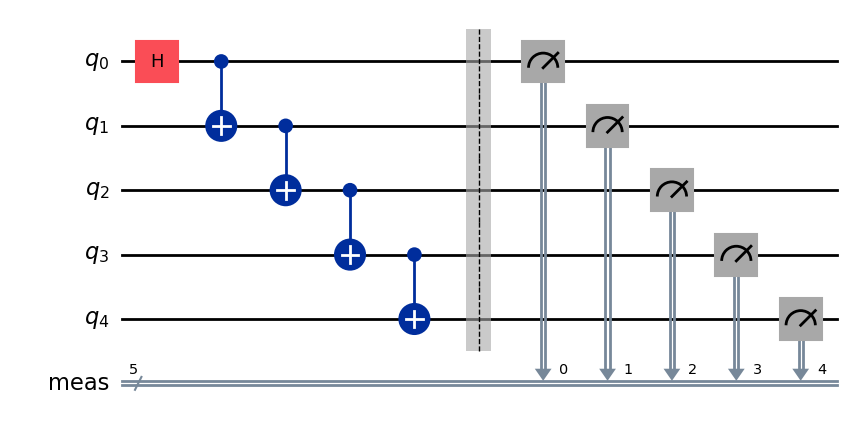

In [36]:
# cell 4 - define quantum circuit
num_qubits = 5
qc = QuantumCircuit(num_qubits)
qc.h(0)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.measure_all()
qc.draw('mpl')

In [37]:
# cell 5 - prepare simulator and transplie circuit
current_sim = AerSimulator()
qc_for_sim = transpile(qc, current_sim, optimization_level=0)
print("Circuit depth:", qc_for_sim.depth())

Circuit depth: 6


In [38]:
# cell 6 - add gate errors + readout errors both scaled
def get_scaled_noise_model(backend, scale_factor):
    props = backend.properties()
    scaled_noise_model = NoiseModel()

    # gate errors
    # loop every gate in backend properties and apply depolarizing error * scale_factor
    for gate in props.gates:
        gate_name = gate.gate
        qubits    = gate.qubits
        raw_err   = 0.0

        for param in gate.parameters:
            if param.name == 'gate_error':
                raw_err = param.value

        scaled_err = max(0.0, min(raw_err * scale_factor, 1.0))

        try:
            if len(qubits) == 1 and scaled_err > 0:
                scaled_noise_model.add_quantum_error(
                    depolarizing_error(scaled_err, 1), gate_name, qubits)
            elif len(qubits) == 2 and scaled_err > 0:
                scaled_noise_model.add_quantum_error(
                    depolarizing_error(scaled_err, 2), gate_name, qubits)
        except Exception:
            pass

    # readout errors
    # scale per-qubit readout error from backend properties
    for qubit in range(backend.num_qubits):
        raw_ro = props.readout_error(qubit)
        p = max(0.0, min(raw_ro * scale_factor, 1.0))
        scaled_noise_model.add_readout_error(
            ReadoutError([[1 - p, p], [p, 1 - p]]), [qubit])

    return scaled_noise_model

In [39]:
# cell 7 - sanity check
props = backend.properties()
for scale, label in [(1.0,'Low'), (5.0,'Medium'), (15.0,'High')]:
    errs = [min(p.value * scale, 1.0)
            for gate in props.gates
            for p in gate.parameters
            if p.name == 'gate_error']
    print(f"[{label}] scale={scale:5.1f}x | avg gate error = {np.mean(errs):.5f}")

[Low] scale=  1.0x | avg gate error = 0.00304
[Medium] scale=  5.0x | avg gate error = 0.01522
[High] scale= 15.0x | avg gate error = 0.04565


In [100]:
# cell 8 - noises and samples config
# adjust classification level for ML
noise_config = {
    'Very_Low':1.0,  # 1.0x (normal backend noise)
    'Low':1.1,       # 1.1x noise
    'Middle':1.2,    # 1.2x noise
    'High':1.3,      # 1.3x noise
    'Very_High':1.4  # 1.4x noise
}

# real-world data distribution
samples_distribution = {
    'Very_Low':1000,
    'Low':1000,       
    'Middle':1000,    
    'High':1000,
    'Very_High':1000
}

In [101]:
# cell 9 - calculate the ideal distribution (5 Qubits GHZ State)
# the ideal GHZ State is always separate '00000' and '11111' state by 50/50 percent
ideal_dist = np.zeros(32)
ideal_dist[0] = 0.5   # '00000' state (index 0)
ideal_dist[31] = 0.5  # '11111' state (index 31)

dataset = []
print("getting data.....")

for label, scale in noise_config.items():
    current_noise_model = get_scaled_noise_model(backend, scale)
    
    current_sim = AerSimulator(
        noise_model=current_noise_model,
        coupling_map=backend.coupling_map,
        basis_gates=backend.operation_names
    )

    qc_for_sim = transpile(qc, current_sim, optimization_level=0)
    print(f"[{label}] Transpiled depth: {qc_for_sim.depth()}")
    
    current_samples = samples_distribution[label]
    for _ in range(current_samples):
        job = current_sim.run(qc_for_sim, shots=4096)
        counts = job.result().get_counts()

        # convert to probability (0-31)
        raw_probs = np.array([counts.get(f'{i:05b}', 0) / 4096 for i in range(32)])

        features = {}
        # 1. Raw bitstring probabilities
        for i in range(32):
            features[f'state_{i:05b}'] = raw_probs[i]

        # 2. advanced feature engineering
        features['entropy'] = -np.sum(raw_probs * np.log2(raw_probs + 1e-12))
        features['pop_00000'] = raw_probs[0]
        features['pop_11111'] = raw_probs[31]
        features['tvd'] = 0.5 * np.sum(np.abs(raw_probs - ideal_dist))
        features['fidelity_est'] = np.sum(np.sqrt(raw_probs * ideal_dist))

        # define label
        features['label'] = label
        dataset.append(features)

df = pd.DataFrame(dataset)
print(f"Extract all data of {len(df)} rows, have {df.shape[1] - 1} features")
df.head()

getting data.....
[Very_Low] Transpiled depth: 8
[Low] Transpiled depth: 8
[Middle] Transpiled depth: 8
[High] Transpiled depth: 8
[Very_High] Transpiled depth: 8
Extract all data of 5000 rows, have 37 features


,state_00000,state_00001,state_00010,state_00011,state_00100,state_00101,state_00110,state_00111,state_01000,state_01001,...,state_11100,state_11101,state_11110,state_11111,entropy,pop_00000,pop_11111,tvd,fidelity_est,label
0,0.403809,0.016357,0.011475,0.002930,0.041748,0.001465,0.002197,0.002686,0.007812,0.000488,...,0.003662,0.013672,0.018311,0.395752,2.255925,0.403809,0.395752,0.200439,0.894170,Very_Low
1,0.402100,0.017578,0.013672,0.004639,0.039551,0.001953,0.000732,0.002930,0.003906,0.000000,...,0.001953,0.010254,0.014160,0.403320,2.218757,0.402100,0.403320,0.194580,0.897452,Very_Low
2,0.407959,0.018799,0.010010,0.002441,0.048584,0.002686,0.001953,0.001221,0.007812,0.000977,...,0.004395,0.012695,0.019775,0.385498,2.253623,0.407959,0.385498,0.206543,0.890673,Very_Low
3,0.404785,0.017334,0.008301,0.002441,0.039795,0.000977,0.000732,0.001953,0.004395,0.000000,...,0.002930,0.012451,0.015869,0.410400,2.151717,0.404785,0.410400,0.184814,0.902871,Very_Low
4,0.400146,0.017822,0.010010,0.003662,0.043457,0.003418,0.001221,0.001953,0.008057,0.000488,...,0.002441,0.009033,0.018799,0.403320,2.232070,0.400146,0.403320,0.196533,0.896361,Very_Low


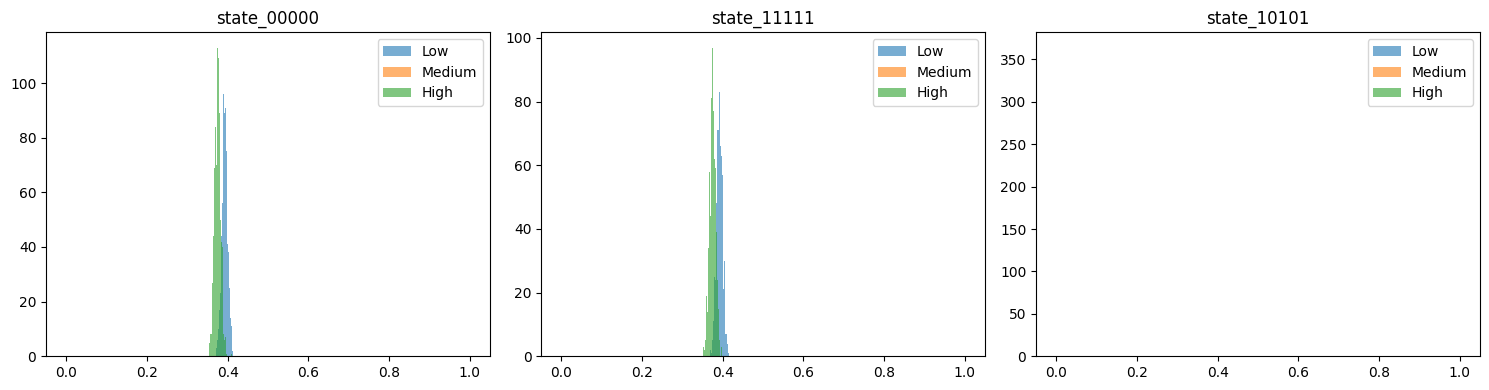

           state_00000  state_11111
label                              
High          0.374704     0.374971
Low           0.392429     0.392281
Middle        0.383206     0.383419
Very_High     0.366208     0.366469
Very_Low      0.401467     0.401318
           state_00000  state_11111
label                              
High          0.007690     0.007663
Low           0.007194     0.007577
Middle        0.007322     0.007580
Very_High     0.007303     0.007254
Very_Low      0.007897     0.007756


In [102]:
# cell 10 - value of state checking before train_test_split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['state_00000', 'state_11111', 'state_10101']):
    for label in ['Low', 'Medium', 'High']:
        subset = df[df['label'] == label][feat]
        ax.hist(subset, bins=30, alpha=0.6, label=label)
    ax.set_title(feat)
    ax.legend()

plt.tight_layout()
plt.show()

# Also print mean per class
print(df.groupby('label')[['state_00000', 'state_11111']].mean())
print(df.groupby('label')[['state_00000', 'state_11111']].std())

🎯 model accuracy: 84.80%

📊 classification report:

               precision    recall  f1-score   support

        High       0.77      0.72      0.75       210
         Low       0.84      0.91      0.88       190
      Middle       0.81      0.77      0.79       192
   Very_High       0.84      0.87      0.85       192
    Very_Low       0.96      0.96      0.96       216

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



<Figure size 800x600 with 0 Axes>

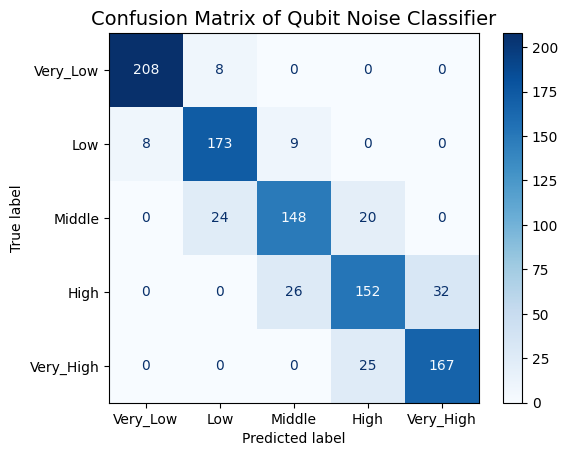

In [120]:
# cell 11 - model training and result visualization
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# 1. extract the features (X) and target/label (y) from the dataFrame.
X = df.drop(columns=['label'])
y = df['label']

# 2. separate the data into two sets (80% for training and 20% for testing accuracy).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. create and train the model (fit) with X_train data
model = RandomForestClassifier(n_estimators=300, 
                               criterion='entropy',
                               max_depth=12, 
                               min_samples_split=2,
                               max_features='sqrt',
                               random_state=42,
                               n_jobs=-1,
                               class_weight='balanced'
                              )
model.fit(X_train, y_train)

# 4. bring the model to predict the test data set to determine the accuracy.
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 5. show the result
print(f"🎯 model accuracy: {accuracy * 100:.2f}%")
print("\n📊 classification report:")
print("\n", classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    labels=['Very_Low', 'Low', 'Middle', 'High', 'Very_High'],
    cmap=plt.cm.Blues                  
)

plt.title("Confusion Matrix of Qubit Noise Classifier", fontsize=14)
plt.show()

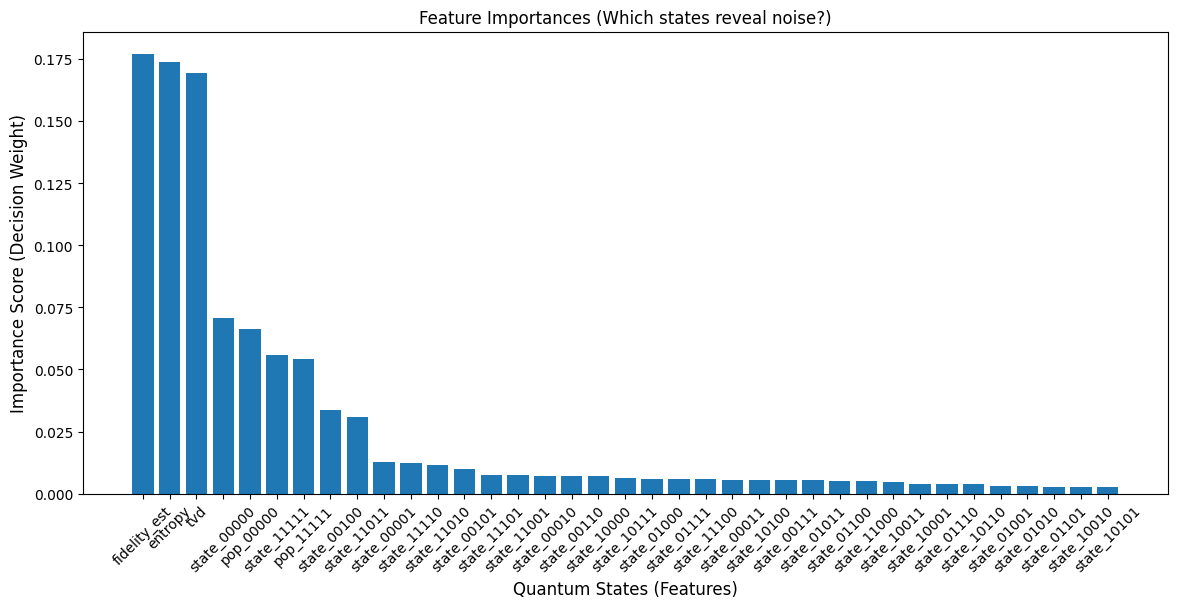

In [121]:
# cell 12 - show relation of graph 
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(14, 6))
plt.title("Feature Importances (Which states reveal noise?)")
plt.bar(range(X.shape[1]), importances[indices],
        align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.xlabel("Quantum States (Features)", fontsize=12)
plt.ylabel("Importance Score (Decision Weight)", fontsize=12)
plt.show()

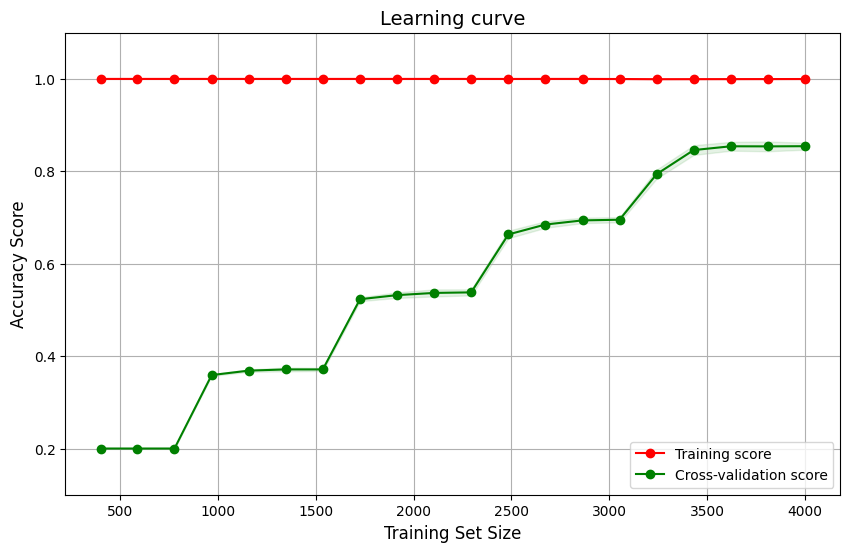

In [122]:
# cell 13 - show learning curve
from sklearn.model_selection import learning_curve

# determine range of datas that use to test (ex.10-100)
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 20)
)

# calculate average and diviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# ploting graph
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")

# decorate the graph
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Learning curve", fontsize=14)
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.ylim(0.1, 1.1)
plt.legend(loc="best")
plt.grid(True)
plt.show()